In [1]:
import Hamiltonian as ham
import PauliStrings as pauli_strings
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol

In [2]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def random_state(n):
    psi = np.transpose(np.random.randn(2**n) + 1j*np.random.randn(2**n))
    return sp.csc_matrix(psi / np.linalg.norm(psi))


In [3]:
#Hamiltonian Params Traverse Field Ising model
n_qubits=6
J=1

#trotter params
H,H_trot=ham.Heisenberg(J,n_qubits)
print('Computing Eigs')
EH,VH = np.linalg.eigh(H.todense())
psigs=VH[:,0]
E_gs=EH[0]
print(H_trot.indk)

Heisenberg model with OBC and Hamiltonian pieces of locality T=2
Succesfull Troterization
The Trotterization consists of 5 terms with the starting qubit of each piece at [0, 1, 2, 3, 4]
Computing Eigs
[0, 1, 2, 3, 4]


In [4]:
print(H_trot.Nk)

5


In [6]:
#Hamiltonian Params Traverse Field Ising model
n_qubits=6
J=1

#trotter params
H,H_trot=ham.Heisenberg(J,n_qubits)
print('Computing Eigs')
EH,VH = np.linalg.eigh(H.todense())
psigs=VH[:,0]
E_gs=EH[0]

#evolution parameters
dt=0.1
N=100
tmax=dt*N
t=0 + np.arange(0, N+1) *dt

#initial state
psi0np=np.zeros((2**n_qubits,1),dtype=complex)
psi0np[0]=1
#psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))
psi_0=np.transpose(random_state(n_qubits))

#QITE and ITE evolution
D=4
print("Computing QITE")
NQ=20
EQ,psi_QITE,aQITE = evol.QITE(n_qubits,H,H_trot,D,psi_0,20,dt,vervose=False,OBC=True)
print("ACQ QITE")
E_ACQ,psi_ACQ,indx,tACQ,aACQ = evol.ACQ(n_qubits,H,H_trot,D,psi_0,N,dt,OBC=True)

#Fidelities
F_ACQ=np.zeros(N+1)
for i in range(N+1):
    F_ACQ[i]=fidelity_pure(psigs,psi_ACQ[:,i].todense())

#Fidelities
F_Q=np.zeros(NQ)
for i in range(NQ):
    F_Q[i]=fidelity_pure(psigs,psi_QITE[:,i].todense())

Heisenberg model with OBC and Hamiltonian pieces of locality T=2
Succesfull Troterization
The Trotterization consists of 5 terms with the starting qubit of each piece at [0, 1, 2, 3, 4]
Computing Eigs
Computing QITE
['I', 'I', 'I', 'I', 'I', 'I']
['I', 'I', 'X', 'I', 'I', 'I']
['I', 'I', 'Y', 'I', 'I', 'I']
['I', 'I', 'Z', 'I', 'I', 'I']
['I', 'X', 'I', 'I', 'I', 'I']
['I', 'X', 'X', 'I', 'I', 'I']
['I', 'X', 'Y', 'I', 'I', 'I']
['I', 'X', 'Z', 'I', 'I', 'I']
['I', 'Y', 'I', 'I', 'I', 'I']
['I', 'Y', 'X', 'I', 'I', 'I']
['I', 'Y', 'Y', 'I', 'I', 'I']
['I', 'Y', 'Z', 'I', 'I', 'I']
['I', 'Z', 'I', 'I', 'I', 'I']
['I', 'Z', 'X', 'I', 'I', 'I']
['I', 'Z', 'Y', 'I', 'I', 'I']
['I', 'Z', 'Z', 'I', 'I', 'I']
['X', 'I', 'I', 'I', 'I', 'I']
['X', 'I', 'X', 'I', 'I', 'I']
['X', 'I', 'Y', 'I', 'I', 'I']
['X', 'I', 'Z', 'I', 'I', 'I']
['X', 'X', 'I', 'I', 'I', 'I']
['X', 'X', 'X', 'I', 'I', 'I']
['X', 'X', 'Y', 'I', 'I', 'I']
['X', 'X', 'Z', 'I', 'I', 'I']
['X', 'Y', 'I', 'I', 'I', 'I']
['X', 'Y'

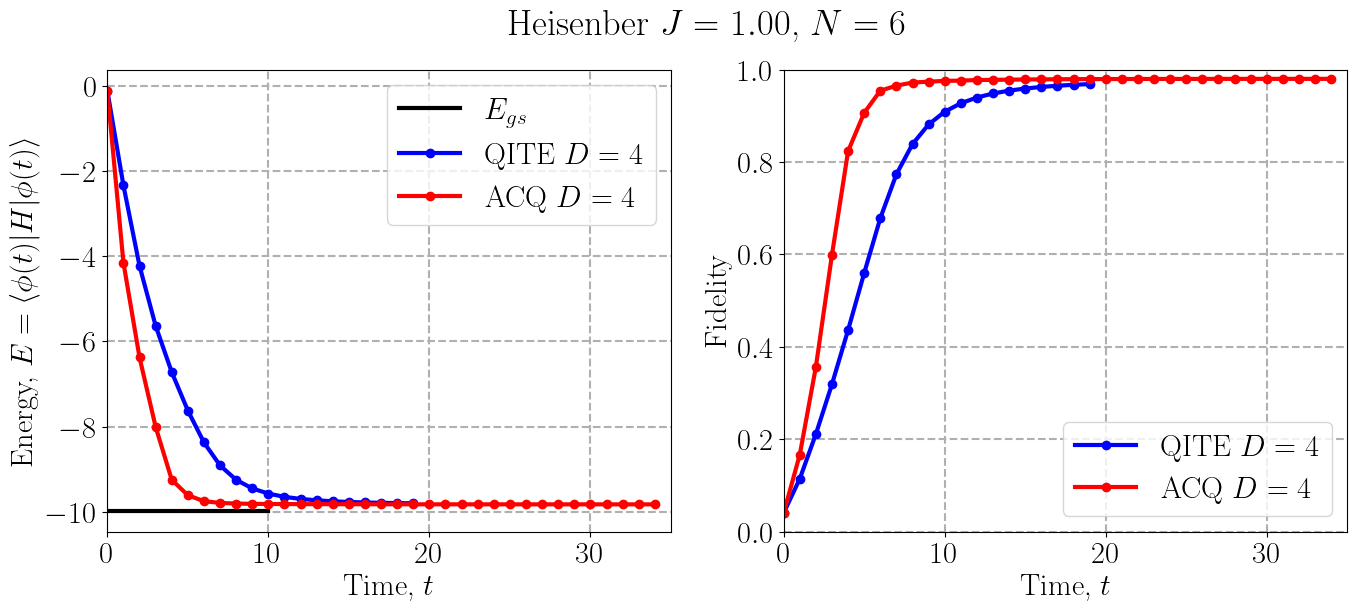

In [7]:
plt.figure(figsize=(16, 6))
plt.rcParams.update({
    "text.usetex": True,
})
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}

plt.rc('font', **font)
plt.suptitle("Heisenber $J=%.2f$,  $N=%d$"%(J,n_qubits))
plt.subplot(1,2,1)
plt.plot(t,t*0+EH[0],'-k',linewidth=3,label='$E_{gs}$')
plt.plot(EQ,'-bo',linewidth=3,label='QITE $D=%d$'%D)
#plt.plot(t,EACQ,'-ro',linewidth=3,label='ACQ $D=%d$'%D)
#plt.plot(t[indx],EACQ[indx],'kx',linewidth=3)
plt.plot(E_ACQ[indx],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
#plt.plot(t[0:NLuca],ELuca,'--bo',linewidth=3,label='AdapQITE $D=%d$'%D)
#plt.plot(t[indxLuca],ELuca[indxLuca],'kx',linewidth=3)
plt.xlabel("Time, $t$")
plt.ylabel("Energy, $E=\\langle \\phi(t)|H|\\phi(t)\\rangle$")
plt.xlim(0,len(indx))
#plt.ylim(-5.5,-4.8)
#plt.ylim([-12,10])
#plt.yticks(np.arange(-12, 10, step=4))
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)
plt.subplot(1,2,2)
plt.plot(F_Q,'-bo',linewidth=3,label='QITE $D=%d$'%D)
#plt.plot(t[0:len(indx)],F1[indx],'-ko',linewidth=3,label='ACQ Exited $D=%d$'%D)
plt.plot(F_ACQ[indx],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
#plt.plot(t,F_ACQ,'-ro',linewidth=3,label='ACQ $D=%d$'%D)
#plt.plot(t[indx],F_ACQ[indx],'kx',linewidth=3)
#plt.plot(t[0:NLuca],F_Luca,'--bo',linewidth=3,label='Luca $D=%d$'%D)
#plt.plot(t[indxLuca],F_Luca[indxLuca],'kx',linewidth=3)
plt.xlabel("Time, $t$")
plt.ylabel("Fidelity")
plt.xlim(0,len(indx))
plt.ylim(0,1)
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)
#plt.savefig("adaptive_QITE_N12D4.png")

In [ ]:
EH[1]-EH[0]

np.float64(1.9663271079575697)